In [1]:
import pandas as pd
import numpy as np

Reading the dataset

In [2]:
data = pd.read_csv("hand_landmarks_data.csv")
data.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


Taking a quick look on the data info and statistics

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [4]:
data.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21
count,25675.000000,25675.000000,2.567500e+04,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,...,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000
mean,201.958632,260.158527,1.272461e-07,202.517395,252.115322,-0.009465,202.862981,240.645966,-0.015946,203.025267,...,-0.024129,201.792374,227.455597,-0.033751,201.811275,227.802576,-0.032208,201.874802,227.807287,-0.028828
std,90.500333,76.533210,2.737932e-07,84.770933,75.384691,0.010376,80.412089,74.721921,0.013973,79.647588,...,0.015658,94.046497,77.231210,0.020453,93.664595,78.441253,0.020877,93.547017,79.963438,0.021136
min,-36.050926,45.722923,-2.029986e-06,7.184681,51.256840,-0.096630,25.114323,45.489950,-0.155846,23.446341,...,-0.201897,0.198635,20.146784,-0.286821,3.278137,32.158108,-0.286470,-4.537216,23.226204,-0.262047
25%,124.110329,205.815950,-5.243216e-08,130.535929,197.999625,-0.015199,136.711035,187.018583,-0.023020,138.905817,...,-0.030728,126.828913,172.720392,-0.042726,126.887403,172.345467,-0.041957,126.356627,172.083794,-0.039220
50%,199.667847,255.181793,1.497277e-07,199.979530,247.113892,-0.008737,200.092758,235.776978,-0.014231,200.482040,...,-0.020969,197.579865,221.781479,-0.029942,197.591736,222.381149,-0.028510,197.453270,222.485229,-0.025269
75%,266.428482,304.991663,2.989988e-07,261.147457,296.850769,-0.002783,255.876354,284.925993,-0.007134,254.622768,...,-0.013661,268.103920,273.190765,-0.019987,267.745743,274.196884,-0.017971,267.324657,275.805222,-0.014294
max,633.556020,781.674469,1.876254e-06,606.232386,751.869416,0.076365,598.541348,719.365010,0.094131,607.999801,...,0.031774,632.923029,779.419948,0.078105,638.134761,760.854103,0.104580,641.788521,760.554894,0.118668


#### Based on previous work on this dataset, the z-axis doesn't contribute to any accuracy gains, so I'll just go ahead and drop it.

In [5]:
zs = [f'z{i}' for i in range(1, 22)]
zs

['z1',
 'z2',
 'z3',
 'z4',
 'z5',
 'z6',
 'z7',
 'z8',
 'z9',
 'z10',
 'z11',
 'z12',
 'z13',
 'z14',
 'z15',
 'z16',
 'z17',
 'z18',
 'z19',
 'z20',
 'z21']

In [6]:
data.drop(columns=zs, axis=1, inplace=True)
data.columns

Index(['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5', 'x6', 'y6',
       'x7', 'y7', 'x8', 'y8', 'x9', 'y9', 'x10', 'y10', 'x11', 'y11', 'x12',
       'y12', 'x13', 'y13', 'x14', 'y14', 'x15', 'y15', 'x16', 'y16', 'x17',
       'y17', 'x18', 'y18', 'x19', 'y19', 'x20', 'y20', 'x21', 'y21', 'label'],
      dtype='object')

<Axes: xlabel='label'>

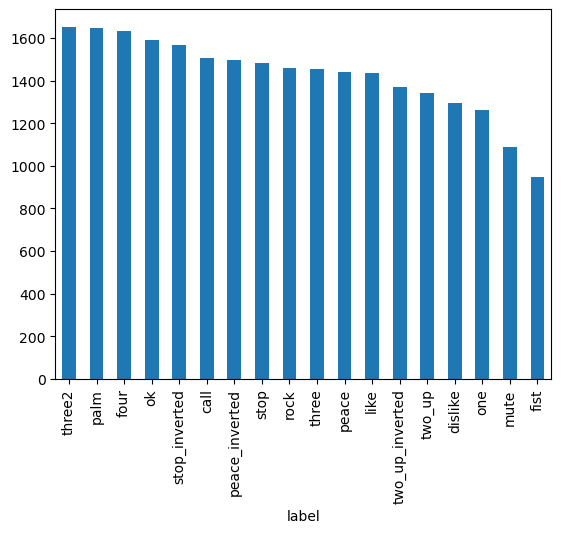

In [7]:
data["label"].value_counts().plot(kind='bar')

the dataset is somewhat unbalanced, `fist` has 945 examples whereas `three2` has 1653
so, when splitting the data, we need to ensure that both training and testing set have equal ratios of classes examples.
this ensures a more honest evaluation of model's metrics

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
X = data.drop(columns='label').copy()
y = data['label'].copy()

for train_idx, test_idx in splitter.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


In [9]:
train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test, y_test], axis=1)

##### `Preprocessing` involves `normalizing` the `position` and `scale` of the hand's `keypoints` by subtracting all keypoints (x_i, y_i) from the wrist position (x1, y1) and dividing all keypoints by the magnitude of the middle finger's tip (x13, y13).

In [10]:
xs = [f'x{i}' for i in range(1, 22)]
ys = [f'y{i}' for i in range(1, 22)]

In [ ]:
# subtract reference point (x1, y1)
train_df[xs] = train_df[xs].sub(train_df['x1'], axis=0)
train_df[ys] = train_df[ys].sub(train_df['y1'], axis=0)

# compute scaling factor
scaling_factor = np.sqrt(
    train_df['x13']**2 + train_df['y13']**2
) + 0.001

# divide (broadcasted row-wise)
train_df[xs] = train_df[xs].div(scaling_factor, axis=0)
train_df[ys] = train_df[ys].div(scaling_factor, axis=0)


# subtract reference point (x1, y1)
test_df[xs] = test_df[xs].sub(test_df['x1'], axis=0)
test_df[ys] = test_df[ys].sub(test_df['y1'], axis=0)


# compute scaling factor
scaling_factor = np.sqrt(
    test_df['x13']**2 + test_df['y13']**2
) + 0.001

# divide (broadcasted row-wise)
test_df[xs] = test_df[xs].div(scaling_factor, axis=0)
test_df[ys] = test_df[ys].div(scaling_factor, axis=0)

In [12]:
train_df.head()

,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,...,y17,x18,y18,x19,y19,x20,y20,x21,y21,label
11158,0.0,0.0,0.200082,-0.063380,0.363619,-0.177795,0.495621,-0.282210,0.623861,-0.340174,...,-0.913888,-0.155527,-0.432807,-0.247245,-0.568376,-0.304480,-0.655643,-0.345636,-0.743521,palm
7813,0.0,0.0,-0.503653,-0.241280,-0.717495,-0.573617,-0.878940,-0.839429,-0.994667,-1.055526,...,-0.431045,0.071140,-0.796737,-0.528266,-0.664226,-0.594296,-0.436617,-0.504226,-0.298480,mute
11589,0.0,0.0,0.179185,-0.086931,0.321617,-0.231109,0.454550,-0.345589,0.580202,-0.408675,...,-0.953625,-0.177179,-0.425175,-0.268160,-0.572218,-0.328130,-0.668937,-0.376319,-0.760276,palm
2130,0.0,0.0,0.212597,0.611858,0.623585,1.195404,0.985073,1.663531,1.179441,2.092436,...,0.101757,1.305669,-0.363374,1.637462,-0.215155,1.283986,-0.153676,1.092878,-0.189138,dislike
15369,0.0,0.0,0.281491,-0.209121,0.396307,-0.573658,0.270715,-0.918941,0.053740,-1.146690,...,-0.993361,-0.150059,-1.111776,-0.215546,-1.505892,-0.281234,-1.727795,-0.298372,-1.920395,rock


### Encoding the label using `Ordinal Encoding` so that the `Neural Network` can deal with it.

In [13]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

train_df[['label']] = encoder.fit_transform(train_df[['label']])
test_df[['label']] = encoder.transform(test_df[['label']])

### Creating the `Dataset Class`.

In [14]:
from torch.utils.data import Dataset
import torch

class HandKeypointsDataset(Dataset):

    def __init__(self, dataframe):
        super().__init__()
        self.X = dataframe.drop(columns=['label']).values
        self.y = dataframe['label'].values

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        features = torch.tensor(self.X[index], dtype=torch.float32)
        label = torch.tensor(self.y[index], dtype=torch.long)
        return features, label

In [ ]:
from torch.utils.data import DataLoader
train_ds = HandKeypointsDataset(train_df)
test_ds = HandKeypointsDataset(test_df)

In [16]:
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)

### Creating the `Neural Network`

In [ ]:
import torch.nn as nn


## This is a simple neural networks that simply consists of a fully connected layer followed by Leaky Relu and Batch Normalization [stacked twice]
## The fully connected layer does a linear combinations between the input features
## Leaky realy introduces non-linearities, beacuse stacking fully connected layers will only result in a Linear Model
## Batch Normalization modifies the distribution of each layer to prevent vanishing/exploding gradients and gives better gradients overall
## Finally, there's a fully connected layer for the final output of the model.
## It has a number of neurons equivalent to the number of outputs
class NeuralNet(nn.Module):
    def __init__(self, *args, **kwargs):
        super(NeuralNet, self).__init__()
        self.linear1 = nn.Linear(in_features=42, out_features=25)
        self.lrelu1 = nn.LeakyReLU(negative_slope=0.01)
        self.bn1 = nn.BatchNorm1d(25)
        
        self.linear2 = nn.Linear(in_features=25, out_features=25)
        self.lrelu2 = nn.LeakyReLU(negative_slope=0.01)
        self.bn2 = nn.BatchNorm1d(25)
        
        self.output = nn.Linear(in_features=25, out_features=18)

    def forward(self, X):
        X = self.linear1(X)
        X = self.lrelu1(X)
        X = self.bn1(X)

        X = self.linear2(X)
        X = self.lrelu2(X)
        X = self.bn2(X)
        
        X = self.output(X)
        return X
    

In [ ]:
import torch

# This function evaluates the model generalization performance by computing the 
# average loss and accuracy of the model over a test data
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for features, labels in loader:
            outputs = model(features)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
from torch.optim import Adam



## Setting up some model and training configurations
## We choose Adam as an optimizer since it's the most commonly used optimizer
## training the model for 50 Epochs
## Computing the loss via CrossEntropyLoss since it's a multi-class classification task

model = NeuralNet()
EPOCHS = 50
criterion = nn.CrossEntropyLoss()
optim = Adam(model.parameters(), lr=0.001)

for epoch in range(1, EPOCHS + 1):

    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for features, labels in train_loader:
        optim.zero_grad()

        ## Forward passing the data through the model
        preds = model(features)
        
        
        labels = labels.long()
        ## Computing the loss
        loss = criterion(preds, labels)
        train_loss += loss.item()
        
        ## Updating the model parameters by computing the gradients and 
        ## performing an update step via the optimizer
        loss.backward()
        optim.step()

        predicted = torch.argmax(preds, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total

    test_loss, test_acc = evaluate(model, test_loader, criterion)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 01 | Train Loss: 1.0491 | Train Acc: 0.7287 | Test Loss: 0.3900 | Test Acc: 0.9073
Epoch 02 | Train Loss: 0.3083 | Train Acc: 0.9198 | Test Loss: 0.1764 | Test Acc: 0.9548
Epoch 03 | Train Loss: 0.1870 | Train Acc: 0.9516 | Test Loss: 0.1341 | Test Acc: 0.9681
Epoch 04 | Train Loss: 0.1546 | Train Acc: 0.9589 | Test Loss: 0.1627 | Test Acc: 0.9634
Epoch 05 | Train Loss: 0.1317 | Train Acc: 0.9640 | Test Loss: 0.0983 | Test Acc: 0.9757
Epoch 06 | Train Loss: 0.1257 | Train Acc: 0.9658 | Test Loss: 0.0924 | Test Acc: 0.9786
Epoch 07 | Train Loss: 0.1196 | Train Acc: 0.9674 | Test Loss: 0.0887 | Test Acc: 0.9805
Epoch 08 | Train Loss: 0.1124 | Train Acc: 0.9685 | Test Loss: 0.1125 | Test Acc: 0.9727
Epoch 09 | Train Loss: 0.1113 | Train Acc: 0.9700 | Test Loss: 0.0849 | Test Acc: 0.9788
Epoch 10 | Train Loss: 0.1044 | Train Acc: 0.9704 | Test Loss: 0.1078 | Test Acc: 0.9708
Epoch 11 | Train Loss: 0.1020 | Train Acc: 0.9711 | Test Loss: 0.0961 | Test Acc: 0.9788
Epoch 12 | Train Loss

`Conclusion`: the model has performed well with an accuracy of ~98.5% on the testing data, as well as a ~98.2% accuracy on the training data which indicates that the model has generalized well on unseen data, and neither overfitting nor underfitting have occurred.